## 1. Setup & Imports

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import ast
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Any
from scipy import interpolate
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = Path('ws25_aia_complete_data')
IMAGES_PATH = Path('images')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# (Important when the notebook uses a dark theme: otherwise axes can look "missing".)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white',
    'savefig.transparent': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'grid.color': '#d0d0d0',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
})

# Use this in *every* plt.savefig to avoid GitLab/dark-mode showing black background
SAVEFIG_KW = dict(facecolor='white', edgecolor='white', transparent=False)

print(f'Dataset path exists: {DATASET_PATH.exists()}')

Dataset path exists: True


## 2. Data Structures

In [51]:
@dataclass
class ScenarioConfig:
    """Scenario configuration parameters."""
    goal_poses: List[Dict]
    start_pose: Dict
    laser_noise_std: float
    laser_drop_pct: float
    map_file: str

@dataclass
class AMCLData:
    """AMCL localization data from rosbag2.csv."""
    timestamps: np.ndarray  # seconds
    positions: np.ndarray   # (N, 3) x, y, z
    orientations: np.ndarray  # (N, 4) w, x, y, z quaternion
    covariances: List[np.ndarray]  # List of 6x6 covariance matrices

@dataclass
class RunMetrics:
    """Computed metrics for a single run."""
    mean_pos_error: float = 0.0
    rmse_pos: float = 0.0
    mean_yaw_error: float = 0.0
    executed_path_length: float = 0.0
    path_efficiency: float = 0.0
    mean_linear_velocity: float = 0.0
    mean_angular_velocity: float = 0.0
    trajectory_smoothness: float = 0.0
    duration: float = 0.0
    mean_amcl_uncertainty: float = 0.0

@dataclass
class RunData:
    """Complete data for a single simulation run."""
    scenario_name: str
    run_id: int
    run_path: Path
    scenario_category: str = ''
    outcome: str = 'unknown'
    poses_df: Optional[pd.DataFrame] = None
    behaviors_df: Optional[pd.DataFrame] = None
    rosbag_df: Optional[pd.DataFrame] = None  # NEW: rosbag2.csv data
    amcl_data: Optional[AMCLData] = None  # NEW: Parsed AMCL data
    config: Optional[ScenarioConfig] = None
    synced_data: Optional[pd.DataFrame] = None
    metrics: Optional[RunMetrics] = None
    anomalies: List[str] = field(default_factory=list)
    time_series_metrics: Optional[pd.DataFrame] = None
    is_valid: bool = True
    error_msg: str = ''

## 3. Data Loading Module

In [52]:
class DatasetLoader:
    """Handles loading and parsing of all dataset files including rosbag2.csv."""
    
    CATEGORY_PATTERNS = {
        'door-width': r'door-width|door-size',
        'room-size': r'room-size',
        'hallway-window': r'hallway-window',
        'everything-failure': r'everything-failure',
        'floorplan-failure': r'floorplan-failure'
    }
    
    def __init__(self, dataset_path: Path):
        self.dataset_path = dataset_path
        
    def get_scenario_category(self, scenario_name: str) -> str:
        import re
        for cat, pattern in self.CATEGORY_PATTERNS.items():
            if re.search(pattern, scenario_name, re.IGNORECASE):
                return cat
        return 'other'
    
    def parse_scenario_config(self, config_path: Path) -> Optional[ScenarioConfig]:
        try:
            with open(config_path, 'r') as f:
                data = yaml.safe_load(f)
            ts = data.get('test_scenario', {})
            return ScenarioConfig(
                goal_poses=ts.get('goal_poses', []),
                start_pose=ts.get('start_pose', {}),
                laser_noise_std=float(ts.get('laserscan_gaussian_noise_std_deviation', 0.02)),
                laser_drop_pct=float(ts.get('laserscan_random_drop_percentage', 0.0)),
                map_file=ts.get('map_file', '')
            )
        except Exception:
            return None
    
    def parse_amcl_data(self, rosbag_df: pd.DataFrame) -> Optional[AMCLData]:
        """Extract AMCL pose data with uncertainty from rosbag2.csv."""
        if rosbag_df is None or rosbag_df.empty:
            return None
        amcl_rows = rosbag_df[rosbag_df['topic'] == '/amcl_pose']
        if amcl_rows.empty:
            return None
        try:
            timestamps = (amcl_rows['timestamp'].values / 1e9).astype(float)
            positions = np.column_stack([
                amcl_rows['pose.pose.position.x'].values,
                amcl_rows['pose.pose.position.y'].values,
                amcl_rows['pose.pose.position.z'].fillna(0).values
            ])
            orientations = np.column_stack([
                amcl_rows['pose.pose.orientation.w'].values,
                amcl_rows['pose.pose.orientation.x'].values,
                amcl_rows['pose.pose.orientation.y'].values,
                amcl_rows['pose.pose.orientation.z'].values
            ])
            # Parse covariance matrices with improved handling
            covariances = []
            for cov_val in amcl_rows['pose.covariance'].values:
                try:
                    if cov_val is None or (isinstance(cov_val, float) and np.isnan(cov_val)):
                        covariances.append(np.eye(6) * 0.01)
                        continue
                    
                    if isinstance(cov_val, str):
                        # Clean string and parse
                        cov_str = cov_val.replace('\n', ' ').replace('[', '').replace(']', '')
                        cov_arr = np.fromstring(cov_str, sep=' ')
                        if len(cov_arr) != 36:
                            # Try comma separation
                            cov_arr = np.fromstring(cov_str, sep=',')
                        if len(cov_arr) != 36:
                            # Try ast.literal_eval as fallback
                            cov_arr = np.array(ast.literal_eval(cov_val.replace('\n', ' ')))
                    elif isinstance(cov_val, (list, np.ndarray)):
                        cov_arr = np.array(cov_val).flatten()
                    else:
                        covariances.append(np.eye(6) * 0.01)
                        continue
                    
                    if len(cov_arr) == 36:
                        cov_matrix = cov_arr.reshape(6, 6)
                        # Validate: covariance diagonal should be non-negative
                        if np.all(np.diag(cov_matrix) >= 0):
                            covariances.append(cov_matrix)
                        else:
                            covariances.append(np.eye(6) * 0.01)
                    else:
                        covariances.append(np.eye(6) * 0.01)
                except Exception:
                    covariances.append(np.eye(6) * 0.01)
            
            return AMCLData(timestamps=timestamps, positions=positions, 
                           orientations=orientations, covariances=covariances)
        except Exception as e:
            return None
    
    def get_run_outcome(self, behaviors_df: pd.DataFrame) -> str:
        if behaviors_df is None or behaviors_df.empty:
            return 'no_data'
        nav = behaviors_df[behaviors_df['behavior_name'].str.contains('nav_through_poses', na=False)]
        if nav.empty:
            return 'no_navigation'
        last_status = nav.iloc[-1]['status_name']
        return 'success' if last_status == 'SUCCESS' else ('failure' if last_status == 'FAILURE' else 'incomplete')
    
    def load_run(self, run_path: Path, scenario_name: str, run_id: int) -> RunData:
        run = RunData(scenario_name=scenario_name, run_id=run_id, run_path=run_path,
                      scenario_category=self.get_scenario_category(scenario_name))
        # Load poses.csv
        poses_path = run_path / 'poses.csv'
        if poses_path.exists():
            try:
                run.poses_df = pd.read_csv(poses_path)
                if run.poses_df.empty:
                    run.is_valid = False
                    run.error_msg = 'Empty poses.csv'
            except Exception as e:
                run.is_valid = False
                run.error_msg = f'Poses error: {e}'
        else:
            run.is_valid = False
            run.error_msg = 'Missing poses.csv'
        # Load behaviors.csv
        behaviors_path = run_path / 'behaviors.csv'
        if behaviors_path.exists():
            try:
                run.behaviors_df = pd.read_csv(behaviors_path)
            except Exception:
                pass
        # Load rosbag2.csv (NEW)
        rosbag_path = run_path / 'rosbag2.csv'
        if rosbag_path.exists():
            try:
                run.rosbag_df = pd.read_csv(rosbag_path, low_memory=False)
                run.amcl_data = self.parse_amcl_data(run.rosbag_df)
            except Exception:
                pass
        # Load config
        config_path = run_path / 'scenario.config'
        if config_path.exists():
            run.config = self.parse_scenario_config(config_path)
        run.outcome = self.get_run_outcome(run.behaviors_df)
        return run
    
    def load_all_runs(self, max_scenarios: int = None) -> List[RunData]:
        runs = []
        scenario_dirs = sorted([d for d in self.dataset_path.iterdir() if d.is_dir()])
        if max_scenarios:
            scenario_dirs = scenario_dirs[:max_scenarios]
        for scenario_dir in tqdm(scenario_dirs, desc='Loading scenarios'):
            scenario_name = scenario_dir.name
            run_dirs = sorted([d for d in scenario_dir.iterdir() if d.is_dir() and d.name.isdigit()])
            for run_dir in run_dirs:
                run = self.load_run(run_dir, scenario_name, int(run_dir.name))
                runs.append(run)
        return runs

loader = DatasetLoader(DATASET_PATH)
print('Loader initialized with rosbag2 support')

Loader initialized with rosbag2 support


## 4. Data Preprocessing Pipeline

In [53]:
class DataPreprocessor:
    """Handles data synchronization and preprocessing."""
    
    @staticmethod
    def normalize_yaw(yaw: np.ndarray) -> np.ndarray:
        return np.arctan2(np.sin(yaw), np.cos(yaw))
    
    @staticmethod
    def quaternion_to_yaw(w, x, y, z):
        """Convert quaternion to yaw angle."""
        siny_cosp = 2 * (w * z + x * y)
        cosy_cosp = 1 - 2 * (y * y + z * z)
        return np.arctan2(siny_cosp, cosy_cosp)
    
    @staticmethod
    def sync_poses(poses_df: pd.DataFrame) -> Optional[pd.DataFrame]:
        if poses_df is None or poses_df.empty:
            return None
        gt_df = poses_df[poses_df['frame'] == 'nav2_turtlebot4_base_link_gt'].copy()
        est_df = poses_df[poses_df['frame'] == 'base_link'].copy()
        if gt_df.empty or est_df.empty:
            return None
        gt_df = gt_df.sort_values('timestamp').drop_duplicates('timestamp')
        est_df = est_df.sort_values('timestamp').drop_duplicates('timestamp')
        est_times = est_df['timestamp'].values
        gt_times = gt_df['timestamp'].values
        if len(gt_times) < 2:
            return None
        valid_mask = (est_times >= gt_times.min()) & (est_times <= gt_times.max())
        est_df = est_df[valid_mask]
        if len(est_df) < 2:
            return None
        synced = est_df.copy()
        synced = synced.rename(columns={'position.x': 'est_x', 'position.y': 'est_y', 'orientation.yaw': 'est_yaw'})
        for col, new_col in [('position.x', 'gt_x'), ('position.y', 'gt_y'), ('orientation.yaw', 'gt_yaw')]:
            f = interpolate.interp1d(gt_times, gt_df[col].values, kind='linear', fill_value='extrapolate')
            synced[new_col] = f(synced['timestamp'].values)
        synced['gt_yaw'] = DataPreprocessor.normalize_yaw(synced['gt_yaw'].values)
        synced['est_yaw'] = DataPreprocessor.normalize_yaw(synced['est_yaw'].values)
        synced = synced[['timestamp', 'est_x', 'est_y', 'est_yaw', 'gt_x', 'gt_y', 'gt_yaw']]
        return synced.reset_index(drop=True)
    
    @staticmethod
    def filter_stationary(synced_df: pd.DataFrame, velocity_threshold: float = 0.01) -> pd.DataFrame:
        if synced_df is None or len(synced_df) < 3:
            return synced_df
        dx = np.diff(synced_df['est_x'].values)
        dy = np.diff(synced_df['est_y'].values)
        dt = np.diff(synced_df['timestamp'].values)
        dt = np.where(dt == 0, 1e-6, dt)
        velocity = np.sqrt(dx**2 + dy**2) / dt
        velocity = np.concatenate([[velocity[0]], velocity])
        moving_mask = velocity > velocity_threshold
        first_moving = np.argmax(moving_mask)
        last_moving = len(moving_mask) - np.argmax(moving_mask[::-1]) - 1
        return synced_df.iloc[first_moving:last_moving+1].reset_index(drop=True)
    
    def preprocess(self, run: RunData, filter_stationary: bool = True) -> RunData:
        if not run.is_valid:
            return run
        synced = self.sync_poses(run.poses_df)
        if synced is None or len(synced) < 10:
            run.is_valid = False
            run.error_msg = 'Sync failed'
            return run
        if filter_stationary:
            synced = self.filter_stationary(synced)
        if synced is None or len(synced) < 5:
            run.is_valid = False
            run.error_msg = 'Too few points after filtering'
            return run
        run.synced_data = synced
        return run

preprocessor = DataPreprocessor()
print('Preprocessor initialized')

Preprocessor initialized


## 5. Metrics

In [54]:
class MetricCalculator:
    """Computes performance metrics including AMCL uncertainty."""
    
    @staticmethod
    def compute_position_error(synced: pd.DataFrame) -> np.ndarray:
        return np.sqrt((synced['est_x'] - synced['gt_x'])**2 + (synced['est_y'] - synced['gt_y'])**2)
    
    @staticmethod
    def compute_yaw_error(synced: pd.DataFrame) -> np.ndarray:
        diff = synced['est_yaw'] - synced['gt_yaw']
        return np.abs(np.arctan2(np.sin(diff), np.cos(diff)))
    
    @staticmethod
    def compute_path_length(x: np.ndarray, y: np.ndarray) -> float:
        return float(np.sum(np.sqrt(np.diff(x)**2 + np.diff(y)**2)))
    
    @staticmethod
    def compute_velocities(synced: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        t = synced['timestamp'].values
        dt = np.diff(t)
        dt = np.where(dt == 0, 1e-6, dt)
        dx = np.diff(synced['est_x'].values)
        dy = np.diff(synced['est_y'].values)
        dyaw = np.diff(synced['est_yaw'].values)
        dyaw = np.arctan2(np.sin(dyaw), np.cos(dyaw))
        linear_vel = np.sqrt(dx**2 + dy**2) / dt
        angular_vel = np.abs(dyaw) / dt
        return linear_vel, angular_vel
    
    @staticmethod
    def compute_trajectory_smoothness(angular_vel: np.ndarray, dt: np.ndarray) -> float:
        if len(angular_vel) < 2:
            return 0.0
        dt_safe = np.where(dt[:-1] == 0, 1e-6, dt[:-1]) if len(dt) > len(angular_vel)-1 else dt
        angular_acc = np.diff(angular_vel) / dt_safe[:len(angular_vel)-1]
        return float(np.mean(np.abs(angular_acc)))
    
    @staticmethod
    def compute_amcl_uncertainty(amcl_data: Optional[AMCLData]) -> float:
        """Compute mean positional uncertainty from AMCL covariance.
        
        Uses sqrt of sum of x,y variances (diagonal elements 0,0 and 1,1).
        This represents the 1-sigma positional uncertainty ellipse size.
        """
        if amcl_data is None or not amcl_data.covariances:
            return 0.0
        
        uncertainties = []
        for cov in amcl_data.covariances:
            try:
                if cov is None or not isinstance(cov, np.ndarray):
                    continue
                if cov.shape != (6, 6):
                    continue
                
                # Extract x and y variances (diagonal elements)
                var_x = cov[0, 0]
                var_y = cov[1, 1]
                
                # Skip invalid values
                if not (np.isfinite(var_x) and np.isfinite(var_y)):
                    continue
                if var_x < 0 or var_y < 0:
                    continue
                
                # Positional uncertainty: sqrt of sum of variances
                # This is the "circular error probable" approximation
                pos_uncertainty = np.sqrt(var_x + var_y)
                
                # Additional sanity check: uncertainty should be reasonable (< 100m)
                if pos_uncertainty < 100.0:
                    uncertainties.append(pos_uncertainty)
            except Exception:
                continue
        
        if not uncertainties:
            return 0.0
        
        return float(np.mean(uncertainties))
    
    def compute_time_series(self, synced: pd.DataFrame) -> pd.DataFrame:
        pos_error = self.compute_position_error(synced)
        yaw_error = self.compute_yaw_error(synced)
        linear_vel, angular_vel = self.compute_velocities(synced)
        ts = pd.DataFrame({
            'timestamp': synced['timestamp'].values,
            'pos_error': pos_error,
            'yaw_error': yaw_error
        })
        ts['linear_vel'] = np.concatenate([[linear_vel[0]], linear_vel])
        ts['angular_vel'] = np.concatenate([[angular_vel[0]], angular_vel])
        return ts
    
    def compute_metrics(self, run: RunData) -> RunData:
        if not run.is_valid or run.synced_data is None:
            return run
        synced = run.synced_data
        pos_error = self.compute_position_error(synced)
        yaw_error = self.compute_yaw_error(synced)
        linear_vel, angular_vel = self.compute_velocities(synced)
        executed_path = self.compute_path_length(synced['est_x'].values, synced['est_y'].values)
        gt_path = self.compute_path_length(synced['gt_x'].values, synced['gt_y'].values)
        dt = np.diff(synced['timestamp'].values)
        mean_amcl = self.compute_amcl_uncertainty(run.amcl_data)
        run.metrics = RunMetrics(
            mean_pos_error=float(np.mean(pos_error)),
            rmse_pos=float(np.sqrt(np.mean(pos_error**2))),
            mean_yaw_error=float(np.mean(yaw_error)),
            executed_path_length=executed_path,
            path_efficiency=gt_path / executed_path if executed_path > 0 else 0,
            mean_linear_velocity=float(np.mean(linear_vel)),
            mean_angular_velocity=float(np.mean(angular_vel)),
            trajectory_smoothness=self.compute_trajectory_smoothness(angular_vel, dt),
            duration=float(synced['timestamp'].iloc[-1] - synced['timestamp'].iloc[0]),
            mean_amcl_uncertainty=mean_amcl
        )
        run.time_series_metrics = self.compute_time_series(synced)
        return run

metric_calculator = MetricCalculator()
print('Metric calculator initialized with AMCL uncertainty')

Metric calculator initialized with AMCL uncertainty


## 6. Anomaly Detection 

In [55]:
class RuleBasedAnomalyDetector:
    """Rule-based anomaly detection using multiple data sources."""
    
    def __init__(self, pos_error_sigma: float = 3.0, consecutive_frames: int = 3):
        self.pos_error_sigma = pos_error_sigma
        self.consecutive_frames = consecutive_frames
        self.global_pos_error_stats = None
    
    def compute_global_stats(self, runs: List[RunData]):
        all_errors = []
        for run in runs:
            if run.is_valid and run.time_series_metrics is not None:
                all_errors.extend(run.time_series_metrics['pos_error'].values)
        if all_errors:
            self.global_pos_error_stats = {'mean': np.mean(all_errors), 'std': np.std(all_errors)}
    
    def detect_goal_failure(self, run: RunData) -> bool:
        return run.outcome == 'failure'
    
    def detect_position_error_spike(self, run: RunData) -> bool:
        if not run.is_valid or run.time_series_metrics is None or self.global_pos_error_stats is None:
            return False
        threshold = self.global_pos_error_stats['mean'] + self.pos_error_sigma * self.global_pos_error_stats['std']
        errors = run.time_series_metrics['pos_error'].values
        above_threshold = errors > threshold
        for i in range(len(above_threshold) - self.consecutive_frames + 1):
            if all(above_threshold[i:i+self.consecutive_frames]):
                return True
        return False
    
    def detect_stuck(self, run: RunData, velocity_threshold: float = 0.01, duration_threshold: float = 5.0) -> bool:
        if not run.is_valid or run.time_series_metrics is None:
            return False
        ts = run.time_series_metrics
        stuck_mask = ts['linear_vel'] < velocity_threshold
        start = None
        for i, is_stuck in enumerate(stuck_mask):
            if is_stuck and start is None:
                start = ts['timestamp'].iloc[i]
            elif not is_stuck and start is not None:
                duration = ts['timestamp'].iloc[i] - start
                if duration > duration_threshold:
                    return True
                start = None
        return False
    
    def detect_high_amcl_uncertainty(self, run: RunData, threshold: float = 0.5) -> bool:
        """Detect high localization uncertainty from AMCL."""
        if run.metrics is None:
            return False
        return run.metrics.mean_amcl_uncertainty > threshold
    
    def detect_high_yaw_error(self, run: RunData, threshold: float = 0.5) -> bool:
        return run.metrics.mean_yaw_error > threshold if run.metrics else False

    def detect_path_inefficiency(self, run: RunData, threshold: float = 0.6) -> bool:
        return run.metrics.path_efficiency < threshold if run.metrics else False
    
    def detect_all(self, run: RunData) -> List[str]:
        anomalies = []
        if self.detect_goal_failure(run):
            anomalies.append('goal_failure')
        if self.detect_position_error_spike(run):
            anomalies.append('position_error_spike')
        if self.detect_stuck(run):
            anomalies.append('stuck')
        if self.detect_high_amcl_uncertainty(run):
            anomalies.append('high_amcl_uncertainty')
        if self.detect_high_yaw_error(run):
            anomalies.append('high_yaw_error')
        if self.detect_path_inefficiency(run):
            anomalies.append('path_inefficiency')
        return anomalies

class MLAnomalyDetector:
    """ML-based anomaly detection using Isolation Forest."""
    
    def __init__(self, contamination: float = 0.1):
        self.contamination = contamination
        self.model = IsolationForest(contamination=contamination, random_state=42, n_estimators=100)
        self.scaler = StandardScaler()
        self.is_fitted = False
    
    def extract_features(self, run: RunData) -> Optional[np.ndarray]:
        if not run.is_valid or run.metrics is None:
            return None
        m = run.metrics
        return np.array([
            m.mean_pos_error, m.rmse_pos, m.mean_yaw_error,
            m.executed_path_length, m.duration, m.path_efficiency,
            m.mean_linear_velocity, m.trajectory_smoothness,
            m.mean_amcl_uncertainty
        ])
    
    def fit(self, runs: List[RunData]):
        features = [self.extract_features(r) for r in runs if r.is_valid and r.metrics is not None]
        features = [f for f in features if f is not None]
        if len(features) < 10:
            return
        X = np.vstack(features)
        X_scaled = self.scaler.fit_transform(X)
        self.model.fit(X_scaled)
        self.is_fitted = True
    
    def predict(self, run: RunData) -> bool:
        if not self.is_fitted:
            return False
        features = self.extract_features(run)
        if features is None:
            return False
        X_scaled = self.scaler.transform(features.reshape(1, -1))
        return self.model.predict(X_scaled)[0] == -1

rule_detector = RuleBasedAnomalyDetector()
ml_detector = MLAnomalyDetector(contamination=0.15)
print('Anomaly detectors initialized with AMCL-based detection')

Anomaly detectors initialized with AMCL-based detection


## 7. Load and Process Data

In [56]:
# Load all runs
print('Loading dataset (this may take a few minutes)...')
all_runs = loader.load_all_runs(max_scenarios=100)  # Set to e.g. 50 for faster processing
print(f'Loaded {len(all_runs)} total runs')

# Count runs with rosbag data
runs_with_rosbag = sum(1 for r in all_runs if r.rosbag_df is not None)
runs_with_amcl = sum(1 for r in all_runs if r.amcl_data is not None)
print(f'Runs with rosbag2.csv: {runs_with_rosbag}')
print(f'Runs with parsed AMCL data: {runs_with_amcl}')

# Preprocess
print('\nPreprocessing...')
for run in tqdm(all_runs, desc='Preprocessing'):
    preprocessor.preprocess(run)

valid_runs = [r for r in all_runs if r.is_valid]
print(f'Valid runs after preprocessing: {len(valid_runs)}')

# Compute metrics
print('\nComputing metrics...')
for run in tqdm(valid_runs, desc='Computing metrics'):
    metric_calculator.compute_metrics(run)

# Anomaly detection
print('\nDetecting anomalies...')
rule_detector.compute_global_stats(valid_runs)
ml_detector.fit(valid_runs)

for run in valid_runs:
    run.anomalies = rule_detector.detect_all(run)
    if ml_detector.predict(run):
        run.anomalies.append('Isolation Forest')

print('\n✅ Processing complete!')

Loading dataset (this may take a few minutes)...


Loading scenarios:   0%|          | 0/100 [00:00<?, ?it/s]

Loaded 300 total runs
Runs with rosbag2.csv: 300
Runs with parsed AMCL data: 300

Preprocessing...


Preprocessing:   0%|          | 0/300 [00:00<?, ?it/s]

Valid runs after preprocessing: 300

Computing metrics...


Computing metrics:   0%|          | 0/300 [00:00<?, ?it/s]


Detecting anomalies...

✅ Processing complete!


All nine anomalies are represented in the data.


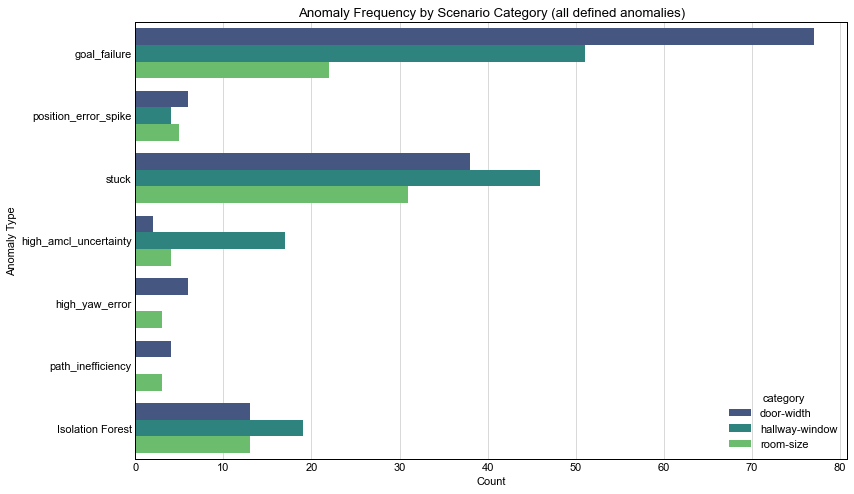

In [57]:
# 9.2 Anomaly distribution by category
ANOM_LABELS = [
    'goal_failure',
    'position_error_spike',
    'stuck',
    'high_amcl_uncertainty',
    'high_yaw_error',
    'path_inefficiency',
    'Isolation Forest'
]

anomaly_data = []
for run in valid_runs:
    for a in run.anomalies:
        anomaly_data.append({'category': run.scenario_category, 'anomaly': a})

if anomaly_data:
    df_anom = pd.DataFrame(anomaly_data)
    categories = sorted(df_anom['category'].unique())
    df_counts = df_anom.value_counts(['anomaly', 'category']).reset_index(name='count')

    # ensure every anomaly/category combo exists (zero if missing)
    grid = pd.DataFrame(
        [{'anomaly': a, 'category': c} for a in ANOM_LABELS for c in categories]
    )
    df_counts = (grid.merge(df_counts, on=['anomaly', 'category'], how='left')
                       .fillna({'count': 0}))

    missing_anoms = [a for a in ANOM_LABELS if df_counts[df_counts['anomaly'] == a]['count'].sum() == 0]
    if missing_anoms:
        print('Anomalies with zero occurrences (reason: not triggered in any run):', missing_anoms)
    else:
        print('All nine anomalies are represented in the data.')

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=df_counts, y='anomaly', x='count', hue='category', ax=ax, palette='viridis')
    ax.set_title('Anomaly Frequency by Scenario Category (all defined anomalies)')
    ax.set_xlabel('Count')
    ax.set_ylabel('Anomaly Type')
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / 'anomaly_by_category.png', dpi=150, **SAVEFIG_KW)
    plt.show()
else:
    print('No anomalies detected to plot.')

## 8. Map Geometry & Feature Engineering

Integrate map geometry from `maps_details.json` and define causal features for anomaly rule derivation.

In [58]:
import json
from shapely.geometry import Point, Polygon, LineString
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Robot Constants
ROBOT_FOOTPRINT = 0.22  # TurtleBot4 diameter in meters
ROBOT_RADIUS = ROBOT_FOOTPRINT / 2
SENSOR_HEIGHT = 0.20  # LiDAR sensor height from ground (20cm)

print(f'Robot Constants: Footprint={ROBOT_FOOTPRINT}m, Sensor Height={SENSOR_HEIGHT}m')

Robot Constants: Footprint=0.22m, Sensor Height=0.2m


In [59]:
class MapGeometry:
    """Loads and provides geometric queries for map features."""
    
    def __init__(self, maps_details_path: Path):
        with open(maps_details_path, 'r') as f:
            self.data = json.load(f)
        self.maps = {}
        self._parse_maps()
        
    def _parse_maps(self):
        for map_info in self.data['maps']:
            map_name = map_info['map']
            spaces = {}
            for space in map_info['spaces']:
                space_name = space['space_name']
                corners = space['corners']
                door = space.get('door', [])
                polygon = Polygon(corners) if len(corners) >= 3 else None
                door_line = LineString(door) if len(door) == 2 else None
                door_width = door_line.length if door_line else 0.0
                spaces[space_name] = {
                    'polygon': polygon, 'corners': corners,
                    'door_line': door_line, 'door_width': door_width,
                    'door_center': door_line.centroid if door_line else None
                }
            self.maps[map_name] = spaces
    
    def get_map_for_scenario(self, scenario_name: str) -> Optional[dict]:
        scenario_lower = scenario_name.lower()
        mapping = {
            '0.3 door': '0-3-door', '0.33 door': '0-33-door', '0.36 door': '0-36-door',
            '0.44 door': '0-44-door', '0.47 door': '0-47-door', 'door_size_0.5': 'door-size-0-5',
            'hallway_window': 'hallway-window', 'room_size_less_50': 'room-size-less-50'
        }
        for map_name, spaces in self.maps.items():
            for key, pattern in mapping.items():
                if key in map_name.lower() and pattern in scenario_lower:
                    return spaces
        return list(self.maps.values())[0] if self.maps else None
    
    def get_corridor_width(self, spaces: dict) -> float:
        if 'corridor' in spaces and spaces['corridor']['polygon']:
            bounds = spaces['corridor']['polygon'].bounds
            return min(bounds[2] - bounds[0], bounds[3] - bounds[1])
        return 1.67
    
    def get_min_door_width(self, spaces: dict) -> float:
        widths = [s['door_width'] for s in spaces.values() if s['door_width'] > 0]
        return min(widths) if widths else 1.0

MAP_GEOMETRY = MapGeometry(Path('maps_details.json'))
print(f'Loaded {len(MAP_GEOMETRY.maps)} maps')

Loaded 10 maps


In [60]:
class ComputableFunctions:
    """Computable functions F - distances, areas, clearances."""
    
    def __init__(self, map_geometry: MapGeometry):
        self.map_geometry = map_geometry
    
    def distance_to_closest_wall(self, x: float, y: float, spaces: dict) -> float:
        point = Point(x, y)
        min_dist = float('inf')
        for space_info in spaces.values():
            if space_info['polygon']:
                min_dist = min(min_dist, point.distance(space_info['polygon'].exterior))
        return min_dist if min_dist != float('inf') else 0.5
    
    def distance_to_closest_door(self, x: float, y: float, spaces: dict) -> Tuple[float, str]:
        point = Point(x, y)
        min_dist, closest_room = float('inf'), None
        for space_name, space_info in spaces.items():
            if space_info['door_center']:
                dist = point.distance(space_info['door_center'])
                if dist < min_dist:
                    min_dist, closest_room = dist, space_name
        return (min_dist if min_dist != float('inf') else 10.0, closest_room)
    
    def door_width_at_location(self, x: float, y: float, spaces: dict) -> float:
        dist, room = self.distance_to_closest_door(x, y, spaces)
        return spaces[room]['door_width'] if room and dist < 1.0 else 1.0
    
    def get_current_room(self, x: float, y: float, spaces: dict) -> Optional[str]:
        point = Point(x, y)
        for space_name, space_info in spaces.items():
            if space_info['polygon'] and space_info['polygon'].contains(point):
                return space_name
        return None
    
    def room_area(self, room_name: str, spaces: dict) -> float:
        if room_name and room_name in spaces and spaces[room_name]['polygon']:
            return spaces[room_name]['polygon'].area
        return 20.0
    
    def goal_to_wall_distance(self, gx: float, gy: float, spaces: dict) -> float:
        return self.distance_to_closest_wall(gx, gy, spaces)
    
    def path_crosses_door(self, sx, sy, gx, gy, spaces: dict) -> bool:
        path = LineString([(sx, sy), (gx, gy)])
        return any(s['door_line'] and path.intersects(s['door_line']) for s in spaces.values())

FUNCTIONS = ComputableFunctions(MAP_GEOMETRY)
print('Computable functions initialized')

Computable functions initialized


In [61]:
class AtomicRelations:
    """Boolean predicates R based on causal features."""
    
    def __init__(self, functions: ComputableFunctions, footprint: float = ROBOT_FOOTPRINT):
        self.F = functions
        self.footprint = footprint
    
    def near_wall(self, x, y, spaces): 
        return self.F.distance_to_closest_wall(x, y, spaces) < self.footprint * 1.5
    def at_door(self, x, y, spaces): 
        return self.F.distance_to_closest_door(x, y, spaces)[0] < 0.5
    def door_too_narrow(self, x, y, spaces): 
        return self.F.door_width_at_location(x, y, spaces) < self.footprint * 1.8
    def in_narrow_corridor(self, spaces): 
        return self.F.map_geometry.get_corridor_width(spaces) < self.footprint * 3
    def in_small_room(self, x, y, spaces):
        room = self.F.get_current_room(x, y, spaces)
        return self.F.room_area(room, spaces) < 5.0 if room else False
    def tight_clearance(self, x, y, spaces): 
        return self.F.distance_to_closest_wall(x, y, spaces) < self.footprint * 1.2
    def in_corridor(self, x, y, spaces): 
        return self.F.get_current_room(x, y, spaces) == 'corridor'
    def goal_near_wall(self, gx, gy, spaces): 
        return self.F.goal_to_wall_distance(gx, gy, spaces) < self.footprint
    def goal_through_door(self, sx, sy, gx, gy, spaces): 
        return self.F.path_crosses_door(sx, sy, gx, gy, spaces)
    def waypoint_in_tight_space(self, gx, gy, spaces): 
        return self.F.distance_to_closest_wall(gx, gy, spaces) < self.footprint * 1.5
    def high_noise(self, noise): 
        return noise > 0.05
    def min_door_narrow(self, spaces): 
        return self.F.map_geometry.get_min_door_width(spaces) < self.footprint * 1.8

RELATIONS = AtomicRelations(FUNCTIONS)
print('Atomic relations initialized: 12 causal predicates')

Atomic relations initialized: 12 causal predicates


In [62]:
class FeatureExtractor:
    """Extract feature vectors for anomaly rule derivation."""
    
    FEATURE_NAMES = [
        'min_wall_distance', 'min_door_distance', 'door_width', 'corridor_width',
        'room_area', 'clearance_ratio', 'goal_wall_distance', 'path_length', 'noise_level',
        'near_wall', 'at_door', 'door_too_narrow', 'in_narrow_corridor', 'in_small_room',
        'tight_clearance', 'in_corridor', 'goal_near_wall', 'goal_through_door',
        'waypoint_in_tight_space', 'high_noise', 'min_door_narrow'
    ]
    
    def __init__(self, map_geometry, relations, functions):
        self.map_geometry, self.R, self.F = map_geometry, relations, functions
    
    def extract_features(self, run: RunData) -> Optional[np.ndarray]:
        if not run.is_valid or run.synced_data is None or run.config is None:
            return None
        spaces = self.map_geometry.get_map_for_scenario(run.scenario_name)
        if not spaces: return None
        
        synced, config = run.synced_data, run.config
        mean_x, mean_y = synced['gt_x'].mean(), synced['gt_y'].mean()
        goals = config.goal_poses
        goal_x = goals[-1].get('position', {}).get('x', 0) if goals else mean_x
        goal_y = goals[-1].get('position', {}).get('y', 0) if goals else mean_y
        start_x = config.start_pose.get('position', {}).get('x', 0)
        start_y = config.start_pose.get('position', {}).get('y', 0)
        noise = config.laser_noise_std
        
        min_wall = self.F.distance_to_closest_wall(mean_x, mean_y, spaces)
        min_door, _ = self.F.distance_to_closest_door(mean_x, mean_y, spaces)
        door_w = self.F.door_width_at_location(mean_x, mean_y, spaces)
        corr_w = self.map_geometry.get_corridor_width(spaces)
        room = self.F.get_current_room(mean_x, mean_y, spaces)
        room_a = self.F.room_area(room, spaces) if room else 20.0
        clearance = min_wall / ROBOT_RADIUS if ROBOT_RADIUS > 0 else 10.0
        goal_wall = self.F.goal_to_wall_distance(goal_x, goal_y, spaces)
        path_len = run.metrics.executed_path_length if run.metrics else 0.0
        
        return np.array([
            min_wall, min_door, door_w, corr_w, room_a, clearance, goal_wall, path_len, noise,
            int(self.R.near_wall(mean_x, mean_y, spaces)),
            int(self.R.at_door(mean_x, mean_y, spaces)),
            int(self.R.door_too_narrow(mean_x, mean_y, spaces)),
            int(self.R.in_narrow_corridor(spaces)),
            int(self.R.in_small_room(mean_x, mean_y, spaces)),
            int(self.R.tight_clearance(mean_x, mean_y, spaces)),
            int(self.R.in_corridor(mean_x, mean_y, spaces)),
            int(self.R.goal_near_wall(goal_x, goal_y, spaces)),
            int(self.R.goal_through_door(start_x, start_y, goal_x, goal_y, spaces)),
            int(self.R.waypoint_in_tight_space(goal_x, goal_y, spaces)),
            int(self.R.high_noise(noise)),
            int(self.R.min_door_narrow(spaces))
        ])

EXTRACTOR = FeatureExtractor(MAP_GEOMETRY, RELATIONS, FUNCTIONS)
print(f'Feature extractor: {len(EXTRACTOR.FEATURE_NAMES)} features (9 continuous + 12 boolean)')

Feature extractor: 21 features (9 continuous + 12 boolean)


In [63]:
# Extract features for all runs
print('Extracting features...')
feature_data, labels, run_info = [], [], []

for run in tqdm(valid_runs, desc='Extracting features'):
    features = EXTRACTOR.extract_features(run)
    if features is not None:
        feature_data.append(features)
        labels.append(1 if run.anomalies else 0)
        run_info.append({'scenario': run.scenario_name, 'run_id': run.run_id, 
                        'anomalies': run.anomalies, 'outcome': run.outcome})

X = np.array(feature_data)
y = np.array(labels)

print(f'\nExtracted features for {len(X)} runs')
print(f'With anomalies: {sum(y)} ({100*sum(y)/len(y):.1f}%)')

feature_df = pd.DataFrame(X, columns=EXTRACTOR.FEATURE_NAMES)
feature_df['has_anomaly'] = y
feature_df['scenario'] = [r['scenario'] for r in run_info]
feature_df['anomalies'] = [','.join(r['anomalies']) for r in run_info]
print('\nFeature statistics:')
print(feature_df[EXTRACTOR.FEATURE_NAMES].describe().round(3))

Extracting features...


Extracting features:   0%|          | 0/300 [00:00<?, ?it/s]


Extracted features for 300 runs
With anomalies: 221 (73.7%)

Feature statistics:
       min_wall_distance  min_door_distance  door_width  corridor_width  \
count            300.000            300.000     300.000         300.000   
mean               0.618              1.321       0.934           1.668   
std                0.413              0.738       0.125           0.004   
min                0.003              0.170       0.301           1.660   
25%                0.281              0.880       0.870           1.670   
50%                0.635              1.157       1.000           1.670   
75%                0.821              1.485       1.000           1.670   
max                2.364              4.567       1.120           1.670   

       room_area  clearance_ratio  goal_wall_distance  path_length  \
count    300.000          300.000             300.000      300.000   
mean      19.624            5.622               0.869       15.159   
std        5.380            3.75

## 9. Pattern Discovery & FOL Rule Extraction

Train Decision Trees per anomaly type and extract First-Order Logic (FOL) rules.

In [64]:
# Create per-anomaly labels
per_anomaly_labels = {anom: np.array([1 if anom in r['anomalies'] else 0 for r in run_info]) 
                      for anom in ANOM_LABELS}

print('Anomaly counts:')
for anom in ANOM_LABELS:
    count = sum(per_anomaly_labels[anom])
    print(f'  {anom}: {count} ({100*count/len(per_anomaly_labels[anom]):.1f}%)')

Anomaly counts:
  goal_failure: 150 (50.0%)
  position_error_spike: 15 (5.0%)
  stuck: 115 (38.3%)
  high_amcl_uncertainty: 23 (7.7%)
  high_yaw_error: 9 (3.0%)
  path_inefficiency: 7 (2.3%)
  Isolation Forest: 45 (15.0%)


In [65]:
# Train Decision Trees per Anomaly Type
decision_trees, tree_reports = {}, {}

for anom in ANOM_LABELS:
    y_anom = per_anomaly_labels[anom]
    if sum(y_anom) < 5: continue
    
    dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                                 class_weight='balanced', random_state=42)
    dt.fit(X, y_anom)
    decision_trees[anom] = dt
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    try:
        y_pred = cross_val_predict(dt, X, y_anom, cv=cv)
    except:
        y_pred = dt.predict(X)
    
    p, r, f1, _ = precision_recall_fscore_support(y_anom, y_pred, average='binary', zero_division=0)
    tree_reports[anom] = {'precision': p, 'recall': r, 'f1': f1, 'support': sum(y_anom)}
    
    print(f'\n{anom}: P={p:.3f}, R={r:.3f}, F1={f1:.3f}')
    top_feat = sorted(zip(EXTRACTOR.FEATURE_NAMES, dt.feature_importances_), key=lambda x: -x[1])[:3]
    print(f'  Top features: {[", ".join([f"{f}:{i:.2f}" for f,i in top_feat if i > 0])]}')


goal_failure: P=0.868, R=0.833, F1=0.850
  Top features: ['path_length:0.80, goal_wall_distance:0.09, clearance_ratio:0.08']

position_error_spike: P=0.189, R=0.667, F1=0.294
  Top features: ['path_length:0.55, in_corridor:0.21, noise_level:0.18']

stuck: P=0.447, R=0.365, F1=0.402
  Top features: ['min_door_distance:0.34, noise_level:0.25, path_length:0.10']

high_amcl_uncertainty: P=0.386, R=0.739, F1=0.507
  Top features: ['path_length:0.68, clearance_ratio:0.14, goal_wall_distance:0.11']

high_yaw_error: P=0.583, R=0.778, F1=0.667
  Top features: ['in_corridor:0.42, path_length:0.34, min_wall_distance:0.24']

path_inefficiency: P=0.375, R=0.429, F1=0.400
  Top features: ['clearance_ratio:0.46, min_door_distance:0.40, in_corridor:0.10']

Isolation Forest: P=0.365, R=0.844, F1=0.510
  Top features: ['path_length:0.39, noise_level:0.27, min_door_narrow:0.17']


In [66]:
# Extract FOL Rules
def extract_rules_from_tree(tree, feature_names, class_name):
    tree_ = tree.tree_
    feature_name = [feature_names[i] if i != -2 else 'undefined' for i in tree_.feature]
    rules = []
    
    def recurse(node, conditions):
        if tree_.feature[node] != -2:
            name, thresh = feature_name[node], tree_.threshold[node]
            recurse(tree_.children_left[node], conditions + [f'{name} <= {thresh:.2f}'])
            recurse(tree_.children_right[node], conditions + [f'{name} > {thresh:.2f}'])
        else:
            values = tree_.value[node][0]
            prob = values[1] / sum(values) if sum(values) > 0 else 0
            if prob >= 0.5 and tree_.n_node_samples[node] >= 3:
                rules.append({'conditions': conditions, 'prob': prob, 
                             'samples': tree_.n_node_samples[node], 'class': class_name})
    recurse(0, [])
    return rules

def format_fol(conditions, class_name):
    bool_feats = {'near_wall', 'at_door', 'door_too_narrow', 'in_narrow_corridor', 'in_small_room',
                  'tight_clearance', 'in_corridor', 'goal_near_wall', 'goal_through_door',
                  'waypoint_in_tight_space', 'high_noise', 'min_door_narrow'}
    formatted = []
    for c in conditions:
        matched = False
        for feat in bool_feats:
            if feat in c:
                if '> 0.5' in c or '> 0' in c: formatted.append(f'{feat}(t)')
                else: formatted.append(f'NOT_{feat}(t)')
                matched = True
                break
        if not matched:
            formatted.append(c)
    return f'ForAll t : {" AND ".join(formatted)} => {class_name}'

print('\n' + '='*70)
print('EXTRACTED FIRST-ORDER LOGIC (FOL) RULES')
print('='*70)

all_fol_rules = {}
for anom, tree in decision_trees.items():
    rules = extract_rules_from_tree(tree, EXTRACTOR.FEATURE_NAMES, anom)
    all_fol_rules[anom] = rules
    if rules:
        print(f'\n{anom}:')
        for i, r in enumerate(rules[:3], 1):
            print(f'  Rule {i} (P={r["prob"]:.2f}, n={r["samples"]}):')
            print(f'    {format_fol(r["conditions"], r["class"])}')


EXTRACTED FIRST-ORDER LOGIC (FOL) RULES

goal_failure:
  Rule 1 (P=1.00, n=11):
    ForAll t : path_length <= 10.44 AND corridor_width <= 1.66 AND goal_wall_distance <= 0.52 => goal_failure
  Rule 2 (P=0.80, n=5):
    ForAll t : path_length <= 10.44 AND corridor_width > 1.66 AND path_length <= 0.41 => goal_failure
  Rule 3 (P=0.83, n=6):
    ForAll t : path_length <= 10.44 AND corridor_width > 1.66 AND path_length > 0.41 AND min_wall_distance <= 0.09 => goal_failure

position_error_spike:
  Rule 1 (P=0.87, n=15):
    ForAll t : path_length > 5.32 AND NOT_in_corridor(t) AND path_length > 30.64 AND goal_wall_distance > 0.84 => position_error_spike
  Rule 2 (P=0.96, n=20):
    ForAll t : path_length > 5.32 AND in_corridor(t) AND noise_level <= 0.00 AND path_length <= 15.05 => position_error_spike

stuck:
  Rule 1 (P=0.50, n=13):
    ForAll t : min_door_distance <= 1.79 AND min_door_distance <= 1.40 AND goal_wall_distance <= 0.25 AND NOT_near_wall(t) => stuck
  Rule 2 (P=1.00, n=7):
    F

In [67]:
# Performance Summary
print('\n' + '='*70)
print('RULE PERFORMANCE SUMMARY')
print('='*70)

perf_df = pd.DataFrame([
    {'Anomaly': a, 'Precision': r['precision'], 'Recall': r['recall'], 
     'F1': r['f1'], 'Support': r['support']}
    for a, r in tree_reports.items()
])
print(perf_df.to_string(index=False))
print(f'\nMean F1: {perf_df["F1"].mean():.3f}')


RULE PERFORMANCE SUMMARY
              Anomaly  Precision   Recall       F1  Support
         goal_failure   0.868056 0.833333 0.850340      150
 position_error_spike   0.188679 0.666667 0.294118       15
                stuck   0.446809 0.365217 0.401914      115
high_amcl_uncertainty   0.386364 0.739130 0.507463       23
       high_yaw_error   0.583333 0.777778 0.666667        9
    path_inefficiency   0.375000 0.428571 0.400000        7
     Isolation Forest   0.365385 0.844444 0.510067       45

Mean F1: 0.519


## 10. Visualizations

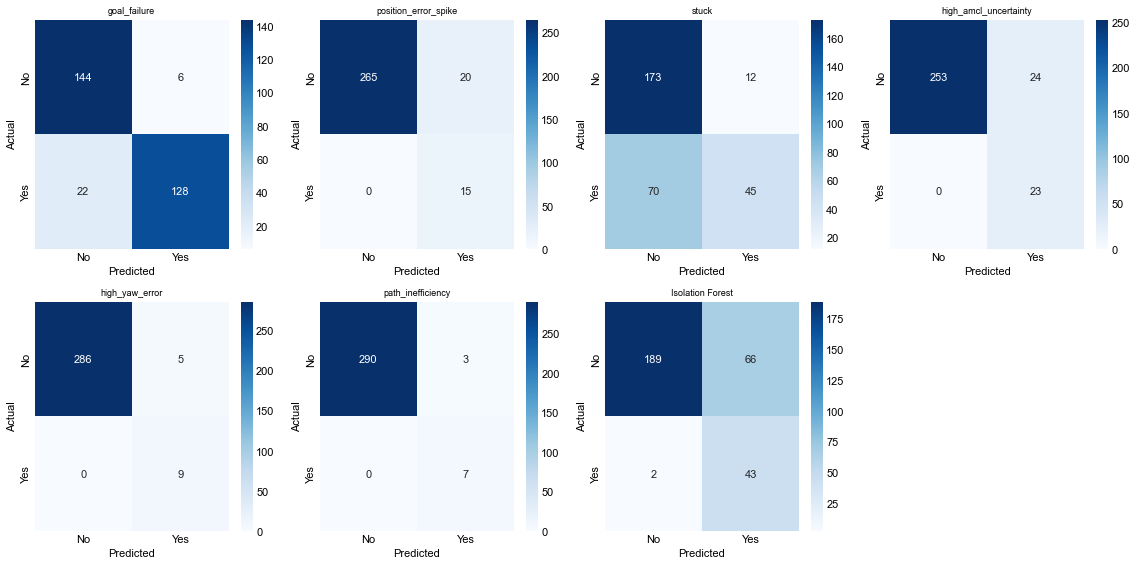

In [68]:
# Confusion Matrices
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (anom, tree) in enumerate(decision_trees.items()):
    if idx >= 8: break
    y_anom, y_pred = per_anomaly_labels[anom], tree.predict(X)
    cm = confusion_matrix(y_anom, y_pred)
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(f'{anom}', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

for idx in range(len(decision_trees), 8): axes[idx].axis('off')
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'confusion_matrices_rules.png', dpi=150, **SAVEFIG_KW)
plt.show()

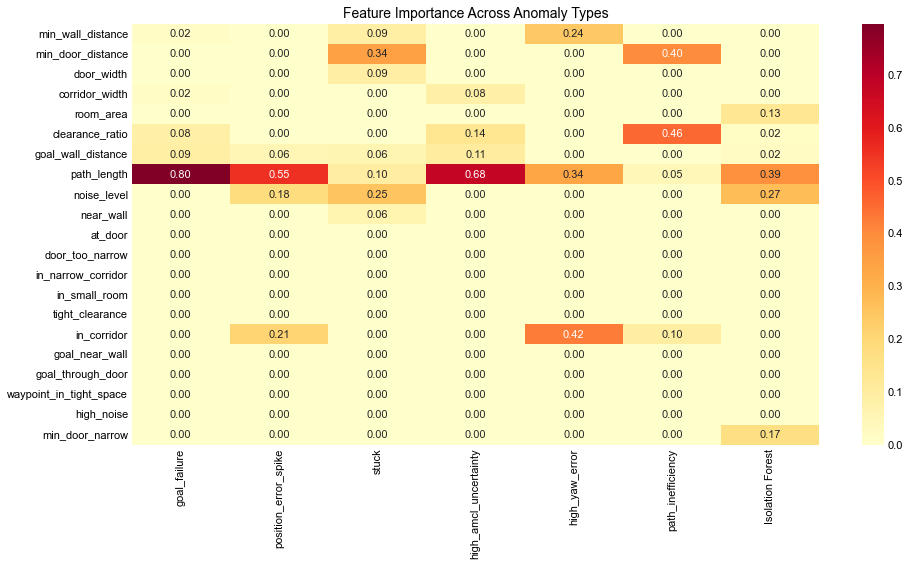

In [69]:
# Feature Importance Heatmap
importance_df = pd.DataFrame(
    [tree.feature_importances_ for tree in decision_trees.values()],
    columns=EXTRACTOR.FEATURE_NAMES,
    index=list(decision_trees.keys())
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(importance_df.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Feature Importance Across Anomaly Types', fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'feature_importance_heatmap.png', dpi=150, **SAVEFIG_KW)
plt.show()

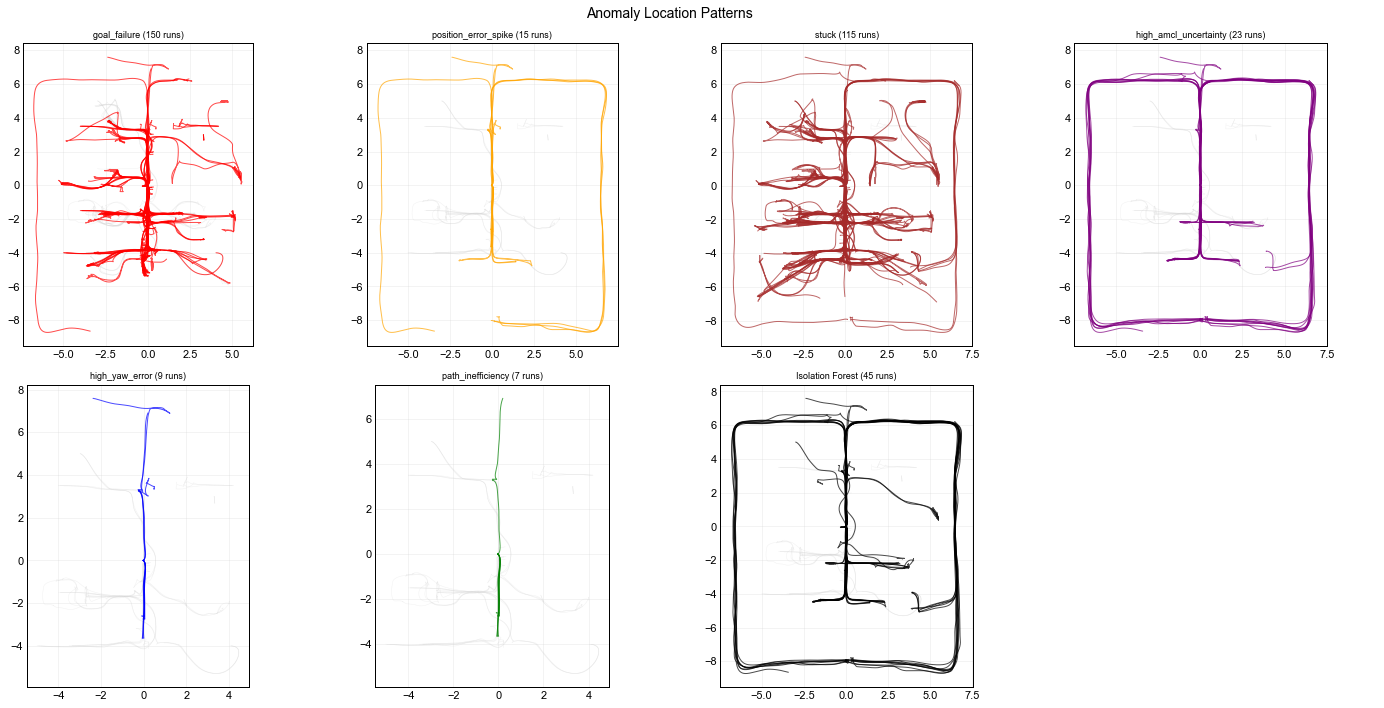

In [70]:
# Anomaly Location Map
anomaly_colors = {'goal_failure': 'red', 'position_error_spike': 'orange', 'stuck': 'brown',
                  'high_amcl_uncertainty': 'purple', 'high_yaw_error': 'blue', 
                  'path_inefficiency': 'green', 'Isolation Forest': 'black'}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, anom in enumerate(ANOM_LABELS[:7]):
    ax = axes[idx]
    anom_runs = [r for r in valid_runs if anom in r.anomalies]
    normal_runs = [r for r in valid_runs if anom not in r.anomalies]
    
    for run in normal_runs[:30]:
        if run.synced_data is not None:
            ax.plot(run.synced_data['gt_x'], run.synced_data['gt_y'], 
                   'lightgray', alpha=0.3, linewidth=0.5)
    for run in anom_runs:
        if run.synced_data is not None:
            ax.plot(run.synced_data['gt_x'], run.synced_data['gt_y'], 
                   color=anomaly_colors.get(anom, 'red'), alpha=0.7, linewidth=1)
    
    ax.set_title(f'{anom} ({len(anom_runs)} runs)', fontsize=9)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

axes[7].axis('off')
plt.suptitle('Anomaly Location Patterns', fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'anomaly_location_map.png', dpi=150, **SAVEFIG_KW)
plt.show()

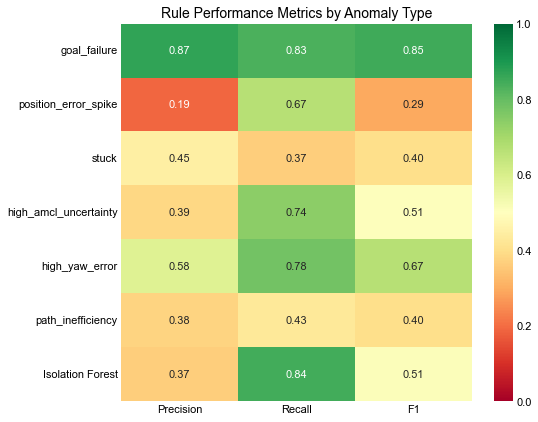

In [71]:
# Rule Performance Heatmap
metrics_df = pd.DataFrame(
    [[r['precision'], r['recall'], r['f1']] for r in tree_reports.values()],
    columns=['Precision', 'Recall', 'F1'],
    index=list(tree_reports.keys())
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(metrics_df, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, vmin=0, vmax=1)
ax.set_title('Rule Performance Metrics by Anomaly Type', fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'rule_performance_heatmap.png', dpi=150, **SAVEFIG_KW)
plt.show()

In [72]:
# Final Summary
print('\n' + '='*70)
print('FINAL SUMMARY: DERIVED FOL RULES FOR ANOMALY PREDICTION')
print('='*70)

for anom, rules in all_fol_rules.items():
    if rules:
        best = max(rules, key=lambda x: x['prob'])
        print(f'\n{anom} (F1={tree_reports[anom]["f1"]:.2f}):')
        print(f'  {format_fol(best["conditions"], best["class"])}')

print('\n All visualizations saved to images/ folder')


FINAL SUMMARY: DERIVED FOL RULES FOR ANOMALY PREDICTION

goal_failure (F1=0.85):
  ForAll t : path_length <= 10.44 AND corridor_width <= 1.66 AND goal_wall_distance <= 0.52 => goal_failure

position_error_spike (F1=0.29):
  ForAll t : path_length > 5.32 AND in_corridor(t) AND noise_level <= 0.00 AND path_length <= 15.05 => position_error_spike

stuck (F1=0.40):
  ForAll t : min_door_distance <= 1.79 AND min_door_distance <= 1.40 AND goal_wall_distance <= 0.25 AND near_wall(t) => stuck

high_amcl_uncertainty (F1=0.51):
  ForAll t : path_length > 30.64 AND goal_wall_distance > 0.79 AND path_length > 33.32 => high_amcl_uncertainty

high_yaw_error (F1=0.67):
  ForAll t : in_corridor(t) AND path_length > 5.25 AND min_wall_distance > 0.62 AND path_length <= 15.61 => high_yaw_error

path_inefficiency (F1=0.40):
  ForAll t : clearance_ratio > 6.87 AND min_door_distance <= 1.25 AND in_corridor(t) AND path_length > 5.00 => path_inefficiency

Isolation Forest (F1=0.51):
  ForAll t : path_length 